# 01 Validation and Exploratory Data Analysis (EDA)

**Purpose:** Validate SQL ground truth metrics against Python-calculated aggregations to ensure strict analytical reconciliation. Once validated, establish a distributional understanding of catalog profitability, operational risk, rank divergence, and discount dependency before any quadrant modeling or scenario simulation begins.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# plotting style for downstream EDA
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Load environment variables
load_dotenv(dotenv_path='../src/config/.env')

DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'password')
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('DB_NAME', 'revenue_rank_reality')

# Establish SQLAlchemy connection
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

print("Environment setup complete. Database connection initialized.")

Environment setup complete. Database connection initialized.


In [2]:
# Load the primary analytical dataframe from the validated SQL export
csv_path = '../data/processed/ground_truth_master.csv'
df = pd.read_csv(csv_path)

print(f"Dataframe loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head(3)

Dataframe loaded successfully: 118 rows, 17 columns.


,product_card_id,product_name,category_name,total_revenue,total_profit,net_profit_pct,revenue_rank,profit_rank,rank_divergence,negative_profit_order_pct,discount_dependency_rate,total_orders,units_sold_per_day,late_delivery_risk_rate,avg_shipping_delay_days,profit_ratio_volatility,delivery_risk_rank
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,6637668.10,731576.18,0.1102,1,1,0,18.36,94.41,16595,14.74,0.5734,0.56,0.4670,43.0
1,365,Perfect Fitness Perfect Rip Deck,Cleats,4233794.25,473820.89,0.1119,2,2,0,18.66,94.41,23478,62.68,0.5739,0.58,0.4567,42.0
2,957,Diamondback Women's Serene Classic Comfort Bi,Camping & Hiking,3946836.86,409895.62,0.1039,3,3,0,18.89,94.41,13157,11.68,0.5691,0.55,0.4693,51.0


## 2. SQL Benchmark Reconciliation
All Python-calculated metrics must reconcile against the SQL ground truth within a ±0.5% tolerance. Any breach stops the pipeline.

In [3]:
# Ground truth targets from methodology_notes.md
sql_benchmarks = {
    'total_unique_products': 118,
    'total_revenue': 35214428.98,
    'avg_profit_ratio': 0.1208,
    'loss_making_products': 118,
    'avg_late_delivery_risk': 0.5729
}

# Re-calculate avg_profit_ratio directly from the fact table to match transactional grain
profit_ratio_query = "SELECT order_item_profit_ratio FROM analytics.fact_orders"
fact_profit_ratios = pd.read_sql(profit_ratio_query, engine)
py_avg_profit_ratio = round(fact_profit_ratios['order_item_profit_ratio'].mean(), 4)

# Python reconstruction from ground_truth_master.csv for the rest
py_metrics = {
    'total_unique_products': df['product_card_id'].nunique(),
    'total_revenue': round(df['total_revenue'].sum(), 2),
    'avg_profit_ratio': py_avg_profit_ratio, 
    'loss_making_products': df[df['negative_profit_order_pct'] > 0]['product_card_id'].nunique(),
    'avg_late_delivery_risk': round((df['late_delivery_risk_rate'] * df['total_orders']).sum() / df['total_orders'].sum(), 4) 
}

# Validation
print("--- RECONCILIATION AUDIT ---")
tolerance = 0.005 # 0.5%
failed = False

for metric, sql_val in sql_benchmarks.items():
    py_val = py_metrics[metric]
    if sql_val == 0:
        diff_pct = 0 if py_val == 0 else 1.0
    else:
        diff_pct = abs((py_val - sql_val) / sql_val)

    status = "PASS" if diff_pct <= tolerance else "FAIL"
    if status == "FAIL":
        failed = True
        
    print(f"{metric:<25} | SQL: {sql_val:<15} | PY: {py_val:<15} | DIFF: {diff_pct:.4%} | {status}")

if failed:
    raise ValueError("FATAL: Ground truth reconciliation failed. Investigate metric divergence before proceeding.")
else:
    print("\nSTATUS: ALL BENCHMARKS RECONCILED WITHIN TOLERANCE.")

--- RECONCILIATION AUDIT ---
total_unique_products     | SQL: 118             | PY: 118             | DIFF: 0.0000% | PASS
total_revenue             | SQL: 35214428.98     | PY: 35214428.98     | DIFF: 0.0000% | PASS
avg_profit_ratio          | SQL: 0.1208          | PY: 0.1208          | DIFF: 0.0000% | PASS
loss_making_products      | SQL: 118             | PY: 118             | DIFF: 0.0000% | PASS
avg_late_delivery_risk    | SQL: 0.5729          | PY: 0.5729          | DIFF: 0.0000% | PASS

STATUS: ALL BENCHMARKS RECONCILED WITHIN TOLERANCE.


## 3. Dataset Shape & Structural Overview
Confirm the structural integrity of the analytical dataframe to ensure no data loss occurred during the export process.

In [4]:
# Structural summary
print("DATASET STRUCTURE")
print(f"Shape: {df.shape[0]} rows (Products) x {df.shape[1]} columns (KPIs)\n")

# Data types and null counts
struct_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Null Count': df.isnull().sum()
})

print(struct_summary)

if df.isnull().sum().sum() == 0:
    print("\nZERO NULLS DETECTED. Dataframe is structurally clean.")
else:
    print("\nNulls detected. Review necessary.")

DATASET STRUCTURE
Shape: 118 rows (Products) x 17 columns (KPIs)

                          Data Type  Null Count
product_card_id               int64           0
product_name                 object           0
category_name                object           0
total_revenue               float64           0
total_profit                float64           0
net_profit_pct              float64           0
revenue_rank                  int64           0
profit_rank                   int64           0
rank_divergence               int64           0
negative_profit_order_pct   float64           0
discount_dependency_rate    float64           0
total_orders                  int64           0
units_sold_per_day          float64           0
late_delivery_risk_rate     float64           0
avg_shipping_delay_days     float64           0
profit_ratio_volatility     float64           0
delivery_risk_rank          float64          46

Nulls detected. Review necessary.


**Business Interpretation:**
172,765 transactions collapsed into 118 product profiles across 17 financial and operational KPIs. Every product is evaluated not just by revenue generated, but by the discount dependency and operational drag required to generate it. The 46 null values in `delivery_risk_rank` are intentional, products with fewer than 100 orders are statistically unreliable for delivery risk ranking and excluded per DL-010.

## 4. Revenue & Profit Distribution
Evaluate the skewness of revenue and profit across the catalog to determine if the business relies on a healthy, distributed product mix or is dangerously concentrated in a few high-volume SKUs.

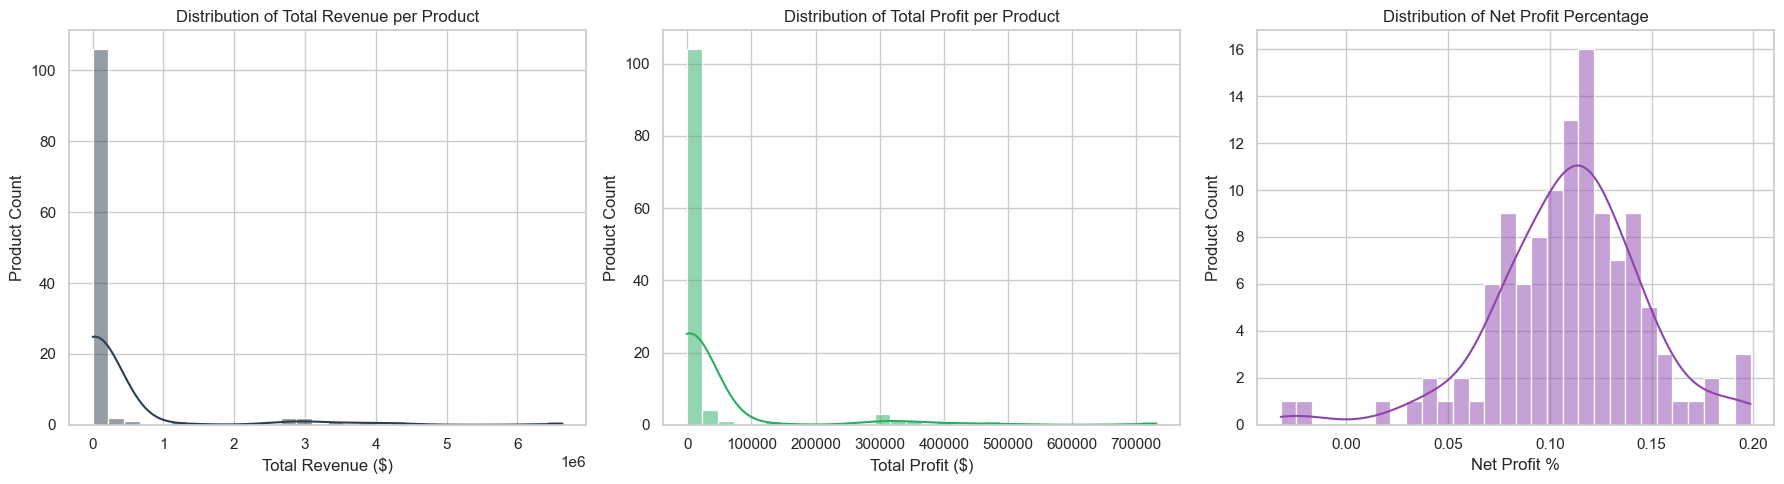

In [5]:
# Plotting distributions for Revenue, Profit, and Margin
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['total_revenue'], bins=30, kde=True, ax=axes[0], color='#2c3e50')
axes[0].set_title('Distribution of Total Revenue per Product')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('Product Count')

sns.histplot(df['total_profit'], bins=30, kde=True, ax=axes[1], color='#27ae60')
axes[1].set_title('Distribution of Total Profit per Product')
axes[1].set_xlabel('Total Profit ($)')
axes[1].set_ylabel('Product Count')

sns.histplot(df['net_profit_pct'], bins=30, kde=True, ax=axes[2], color='#8e44ad')
axes[2].set_title('Distribution of Net Profit Percentage')
axes[2].set_xlabel('Net Profit %')
axes[2].set_ylabel('Product Count')

plt.tight_layout()
plt.show()

In [6]:
# Identify Top 5 and Bottom 5 for each metric
metrics_to_check = {
    'total_revenue': 'Total Revenue ($)',
    'total_profit': 'Total Profit ($)',
    'net_profit_pct': 'Net Profit (%)'
}

for col, label in metrics_to_check.items():
    print(f"\n{'='*40}")
    print(f"{label.upper()}")
    print(f"{'='*40}")
    
    top_5 = df.nlargest(5, col)[['product_card_id', 'product_name', col]]
    bottom_5 = df.nsmallest(5, col)[['product_card_id', 'product_name', col]]
    
    print("TOP 5:")
    print(top_5.to_string(index=False))
    print("\nBOTTOM 5:")
    print(bottom_5.to_string(index=False))


TOTAL REVENUE ($)
TOP 5:
 product_card_id                                  product_name  total_revenue
            1004     Field & Stream Sportsman 16 Gun Fire Safe     6637668.10
             365              Perfect Fitness Perfect Rip Deck     4233794.25
             957 Diamondback Women's Serene Classic Comfort Bi     3946836.86
             191             Nike Men's Free 5.0+ Running Shoe     3507549.21
             502          Nike Men's Dri-FIT Victory Golf Polo     3011600.00

BOTTOM 5:
 product_card_id                           product_name  total_revenue
            1348                            CDs of rock        2969.27
             860 Bushnell Pro X7 Jolt Slope Rangefinder        4799.92
             311            Polar Loop Activity Tracker        5277.60
            1361                                  Toys         5850.78
             226      Bowflex SelectTech 1090 Dumbbells        5999.90

TOTAL PROFIT ($)
TOP 5:
 product_card_id                            

**Business Interpretation:**

* **Zero Rank Divergence at the Top, But at What Cost?** The top 5 revenue products are identically the top 5 profit products in absolute terms. This appears healthy until discount dependency and loss-order rates are layered in, explored in subsequent sections.

* **Revenue and Profit Are Right-Skewed; Margin Is Not.** The catalog is commercially concentrated, a small number of SKUs generate the overwhelming majority of revenue and absolute profit. Net profit percentage, however, distributes more evenly, meaning margin efficiency is not a privilege of high-volume products.

* **The Volume-Margin Disconnect.** The most margin-efficient products, Polar FT4 (19.86%), Bowflex SelectTech 1090 (19.85%), rank near the bottom on revenue. They generate clean profit but lack the transaction volume to meaningfully influence aggregate business health.

* **Lifecycle Net-Negative Products Confirmed.** SOLE E35 (−\\$965) and SOLE E25 (−\\$169) are net-negative across their entire three-year operational history. These are not underperformers, they are value destroyers the business has been operationally sustaining at a confirmed aggregate loss.

## 5. Rank Divergence Overview
Identify products that project the illusion of commercial strength (high revenue rank) while suffering from operational drag (low profit rank).

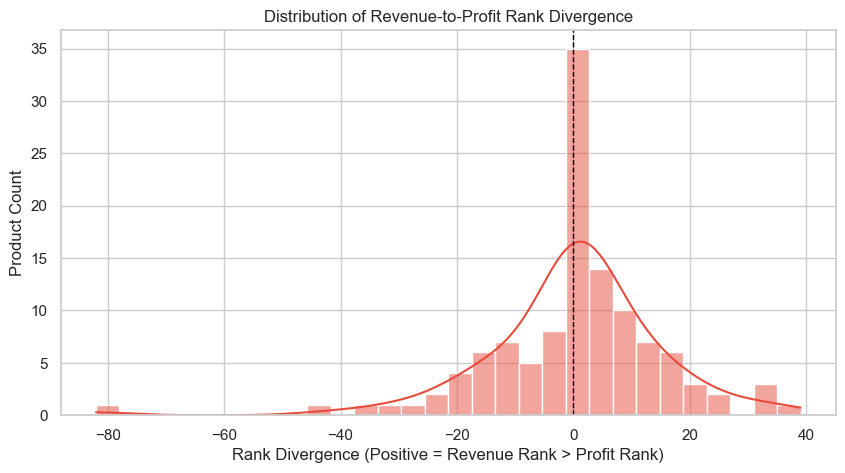

TOP 10 REVENUE TRAPS (High Revenue Rank, Poor Profit Rank):
 product_card_id                                  product_name  revenue_rank  profit_rank  rank_divergence  net_profit_pct
             208                           SOLE E35 Elliptical            36          118              -82         -0.0322
            1357                               Men's gala suit            28           70              -42          0.0438
             828 Bridgestone e6 Straight Distance NFL San Dieg            40           74              -34          0.0629
             203             GoPro HERO3+ Black Edition Camera            85          116              -31          0.0192
             303             Garmin Forerunner 910XT GPS Watch            82          110              -28          0.0338
             977                      ENO Atlas Hammock Straps            37           61              -24          0.0758
             282      Under Armour Women's Ignite PIP VI Slide            43   

In [7]:
# Distribution of Rank Divergence
plt.figure(figsize=(10, 5))
sns.histplot(df['rank_divergence'], bins=30, kde=True, color='#e74c3c')
plt.title('Distribution of Revenue-to-Profit Rank Divergence')
plt.xlabel('Rank Divergence (Positive = Revenue Rank > Profit Rank)')
plt.ylabel('Product Count')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.show()

# Top 10 Divergence Traps (Revenue Traps)
divergence_traps = df.sort_values(by='rank_divergence', ascending=True).head(10)
print("TOP 10 REVENUE TRAPS (High Revenue Rank, Poor Profit Rank):")
print(divergence_traps[['product_card_id', 'product_name', 'revenue_rank', 'profit_rank', 'rank_divergence', 'net_profit_pct']].to_string(index=False))

**Business Interpretation:**
* **The SOLE Elliptical Crisis:** The `SOLE E35 Elliptical` is the ultimate revenue illusion. It sits in the top third of the catalog for revenue (Rank 36) but is dead last in profit (Rank 118), operating at a net negative margin (-3.2%). It is actively burning cash while looking like a commercial success.
* **High-Ticket Margin Killers:** Expensive electronics and gear like the `GoPro HERO3+` and `Garmin Forerunner 910XT` drive high top-line revenue but yield miserable margins (1.9% and 3.3% respectively). 
* **The Revenue Trap:** These products justify their existence on standard commercial dashboards through sheer volume, but operationally, they are massive drags on aggregate profitability.

## 6. Discount Dependency Distribution
Examine how heavily the catalog relies on promotional discounting to drive transactions, and whether this dependency correlates with margin destruction.

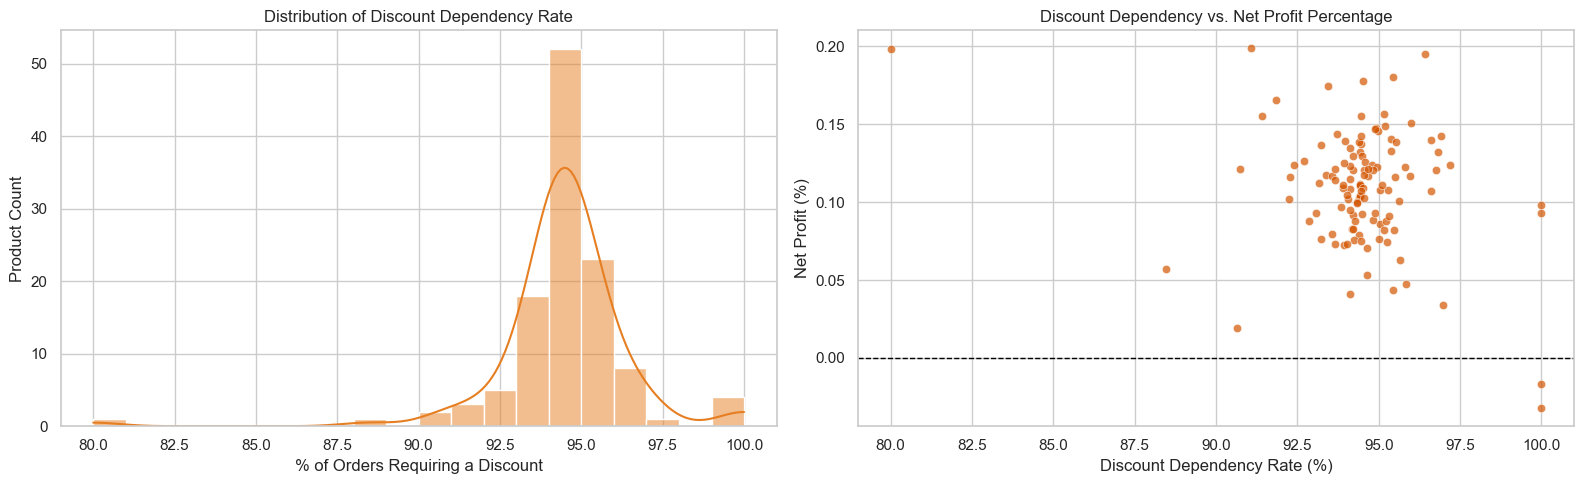

In [8]:
# Plotting Discount Dependency and its relationship with Profit Margin
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['discount_dependency_rate'], bins=20, kde=True, ax=axes[0], color='#e67e22')
axes[0].set_title('Distribution of Discount Dependency Rate')
axes[0].set_xlabel('% of Orders Requiring a Discount')
axes[0].set_ylabel('Product Count')

sns.scatterplot(data=df, x='discount_dependency_rate', y='net_profit_pct', alpha=0.7, color='#d35400', ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Discount Dependency vs. Net Profit Percentage')
axes[1].set_xlabel('Discount Dependency Rate (%)')
axes[1].set_ylabel('Net Profit (%)')

plt.tight_layout()
plt.show()

**Business Interpretation:**
* **Systemic Promotional Reliance:** The catalog is entirely addicted to discounting. The histogram shows a massive concentration between 93% and 97% dependency. There is no meaningful volume of products selling at full retail price.
* **The "Discount Constant":** The scatter plot reveals a tight cluster rather than a linear trend. Because virtually every product requires a discount to move, discounting acts as a baseline structural cost rather than a variable tactic. We cannot conclude that *higher* discounting drives *lower* margins, because there is no non-discounted control group. The business simply does not know how to sell without a promotion.

## 7. Delivery Risk Distribution
Evaluate the concentration of late delivery risk across the catalog.
**Note**: Products with fewer than 100 total orders are excluded from this specific ranking to prevent statistical noise from low-volume SKUs.

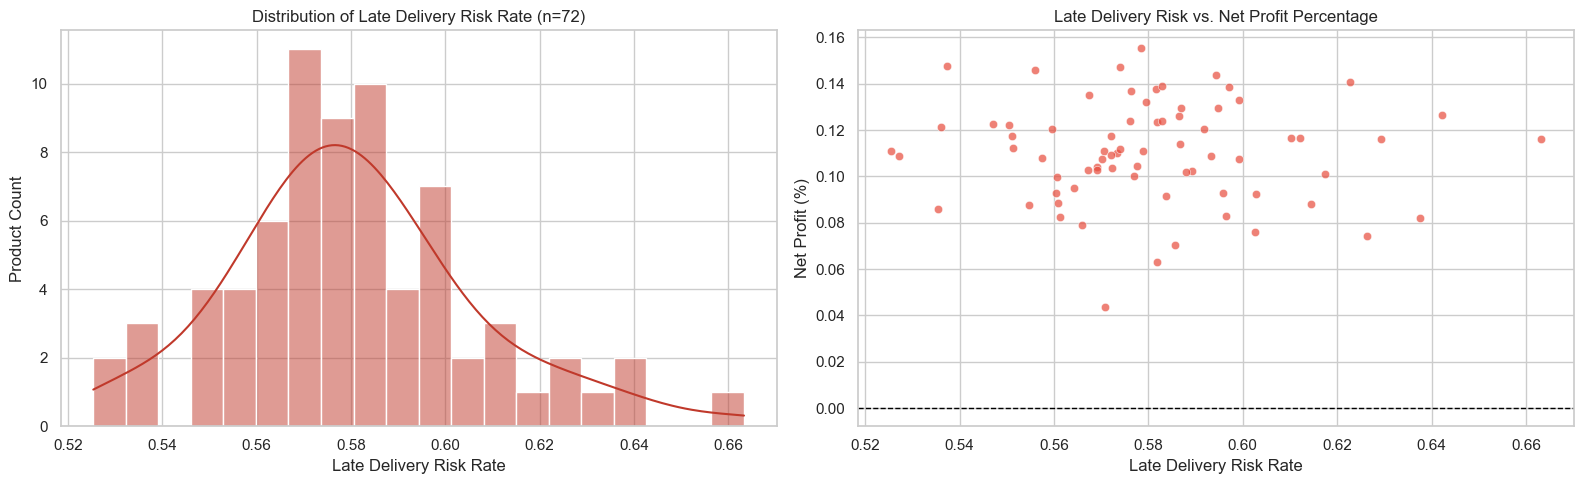

In [9]:
# Isolate valid products using the previously established null threshold in delivery_risk_rank
risk_df = df.dropna(subset=['delivery_risk_rank'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(risk_df['late_delivery_risk_rate'], bins=20, kde=True, ax=axes[0], color='#c0392b')
axes[0].set_title(f'Distribution of Late Delivery Risk Rate (n={len(risk_df)})')
axes[0].set_xlabel('Late Delivery Risk Rate')
axes[0].set_ylabel('Product Count')

sns.scatterplot(data=risk_df, x='late_delivery_risk_rate', y='net_profit_pct', alpha=0.7, color='#e74c3c', ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Late Delivery Risk vs. Net Profit Percentage')
axes[1].set_xlabel('Late Delivery Risk Rate')
axes[1].set_ylabel('Net Profit (%)')

plt.tight_layout()
plt.show()

In [10]:
# compounded risk candidates: High delivery risk (>60%), high discount dependency (>90%), below-average margin (<10%)
compounded_risk = risk_df[
    (risk_df['late_delivery_risk_rate'] > 0.60) & 
    (risk_df['discount_dependency_rate'] > 90.0) & 
    (risk_df['net_profit_pct'] < 0.10)
].sort_values(by='net_profit_pct', ascending=True)

print(f"Compounded Risk Candidates: {len(compounded_risk)} products")
print("These products fail operationally (late >60%), commercially (discounted >90%), and financially (margin <10%):")
print(compounded_risk[['product_card_id', 'product_name', 'late_delivery_risk_rate', 'discount_dependency_rate', 'net_profit_pct']].to_string(index=False))

Compounded Risk Candidates: 5 products
These products fail operationally (late >60%), commercially (discounted >90%), and financially (margin <10%):
 product_card_id                                  product_name  late_delivery_risk_rate  discount_dependency_rate  net_profit_pct
             282      Under Armour Women's Ignite PIP VI Slide                   0.6264                     95.24          0.0741
             977                      ENO Atlas Hammock Straps                   0.6026                     94.23          0.0758
             797          Hirzl Women's Soffft Flex Golf Glove                   0.6376                     95.47          0.0819
            1359                            Adult dog supplies                   0.6144                     94.28          0.0880
             249 Under Armour Women's Micro G Skulpt Running S                   0.6029                     94.49          0.0924


**Business Interpretation:**
* **The Toxic Core:** I have isolated 5 products that represent the worst-case operational scenario. They fail on all three fronts: they require near-constant discounting to move (>94% dependency), they frustrate customers by arriving late more often than not (>60% risk), and they yield miserable margins (<10%). 
* **Brand Execution Failure:** Notable name brands like Under Armour (Ignite Slide, Micro G Skulpt) and ENO are caught in this trap. The business is leveraging recognized brands to drive top-line volume, but actively damaging its operational reputation and bleeding margin due to fulfillment incompetence on those exact SKUs.

## 8. Profit Ratio Volatility
Analyze the standard deviation of the profit ratio across transactions. High volatility indicates unstable pricing, erratic discounting, or fluctuating fulfillment costs, making financial forecasting impossible.

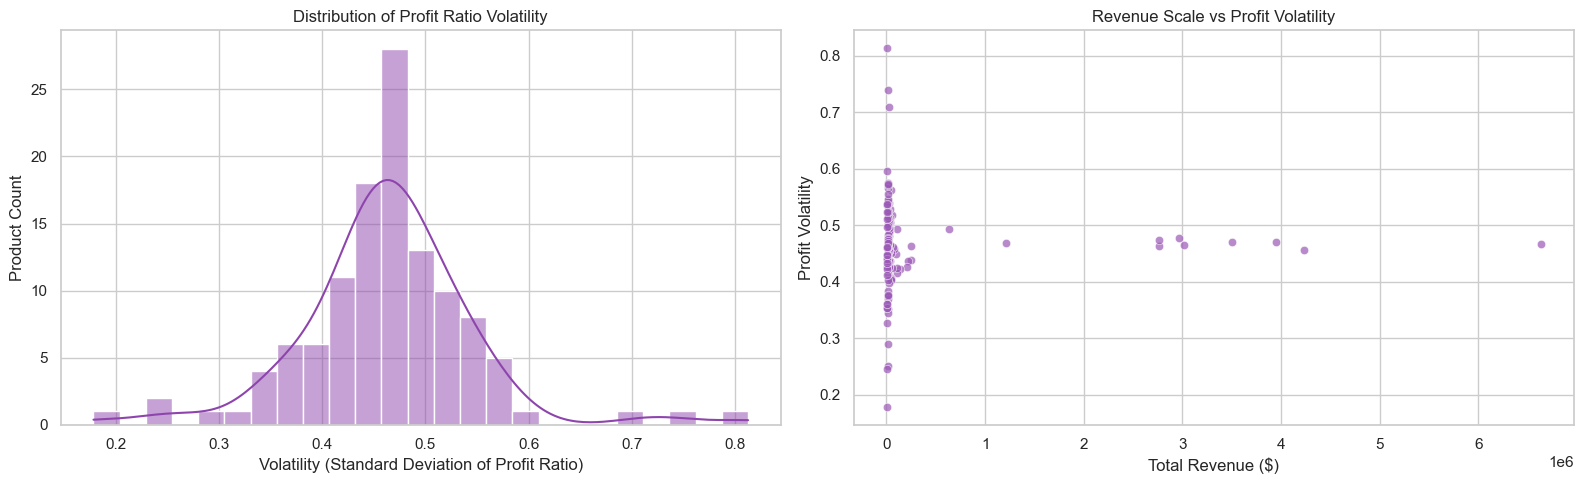

In [11]:
# Plotting Volatility Distribution and its relationship with Scale
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['profit_ratio_volatility'], bins=25, kde=True, ax=axes[0], color='#8e44ad')
axes[0].set_title('Distribution of Profit Ratio Volatility')
axes[0].set_xlabel('Volatility (Standard Deviation of Profit Ratio)')
axes[0].set_ylabel('Product Count')

sns.scatterplot(data=df, x='total_revenue', y='profit_ratio_volatility', alpha=0.7, color='#9b59b6', ax=axes[1])
axes[1].set_title('Revenue Scale vs Profit Volatility')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_ylabel('Profit Volatility')

plt.tight_layout()
plt.show()

In [12]:
# Identify the most volatile products and cross-reference with revenue scale
highly_volatile = df.sort_values(by='profit_ratio_volatility', ascending=False).head(10)

print("TOP 10 MOST VOLATILE PRODUCTS (Highest Margin Unpredictability):")
print(highly_volatile[['product_card_id', 'product_name', 'profit_ratio_volatility', 'net_profit_pct', 'revenue_rank']].to_string(index=False))

TOP 10 MOST VOLATILE PRODUCTS (Highest Margin Unpredictability):
 product_card_id                                  product_name  profit_ratio_volatility  net_profit_pct  revenue_rank
              60                           SOLE E25 Elliptical                   0.8127         -0.0170            98
             203             GoPro HERO3+ Black Edition Camera                   0.7398          0.0192            85
             208                           SOLE E35 Elliptical                   0.7092         -0.0322            36
              19       Nike Men's Fingertrap Max Training Shoe                   0.5951          0.0730           110
             646    Merrell Women's Grassbow Sport Hiking Shoe                   0.5743          0.0879            54
             216 Yakima DoubleDown Ace Hitch Mount 4-Bike Rack                   0.5727          0.0822            91
             295 Fitbit The One Wireless Activity & Sleep Trac                   0.5711          0.1074      

**Business Interpretation:**
* **The Chaos of the Revenue Traps:** The most volatile products in the catalog, the SOLE Ellipticals (0.81 and 0.70 SD) and the GoPro HERO3+ (0.73 SD) are the exact same SKUs I previously identified as margin-destroying revenue traps. Not only do these products lose money, but their unit economics are completely erratic. The business has zero control or predictability over their fulfillment costs or promotional floors.
* **Stable Mediocrity at the Top:** The scatter plot reveals a distinct pattern: extreme margin unpredictability (spikes up to 0.8) is heavily clustered at the lower and middle revenue tiers. The highest-revenue products (the dots extending to the right) stabilize at a baseline volatility of roughly 0.46. Their margins are predictable, but they are predictably locked into the systemic ~11% return and 94% discount dependency I observed earlier.

## 9. Temporal Revenue & Profit Trends
Evaluate macroeconomic trends across the three-year dataset using direct SQLAlchemy queries to the fact table. Are margins eroding over time, or is the operational drag relatively constant?

In [13]:
# Query monthly aggregations directly from the SQL engine
temporal_query = """
SELECT 
    d.year,
    d.month,
    TO_DATE(d.year::TEXT || '-' || LPAD(d.month::TEXT, 2, '0') || '-01', 'YYYY-MM-DD') AS month_date,
    SUM(f.sales) AS total_revenue,
    SUM(f.order_profit_per_order) AS total_profit,
    AVG(f.order_item_profit_ratio) AS avg_profit_ratio,
    AVG(f.late_delivery_risk) AS avg_delivery_risk
FROM analytics.fact_orders f
JOIN analytics.dim_date d ON f.date_id = d.date_id
GROUP BY d.year, d.month
ORDER BY d.year, d.month;
"""

temporal_df = pd.read_sql(temporal_query, engine)
print(f"Temporal data loaded: {len(temporal_df)} months.")

Temporal data loaded: 37 months.


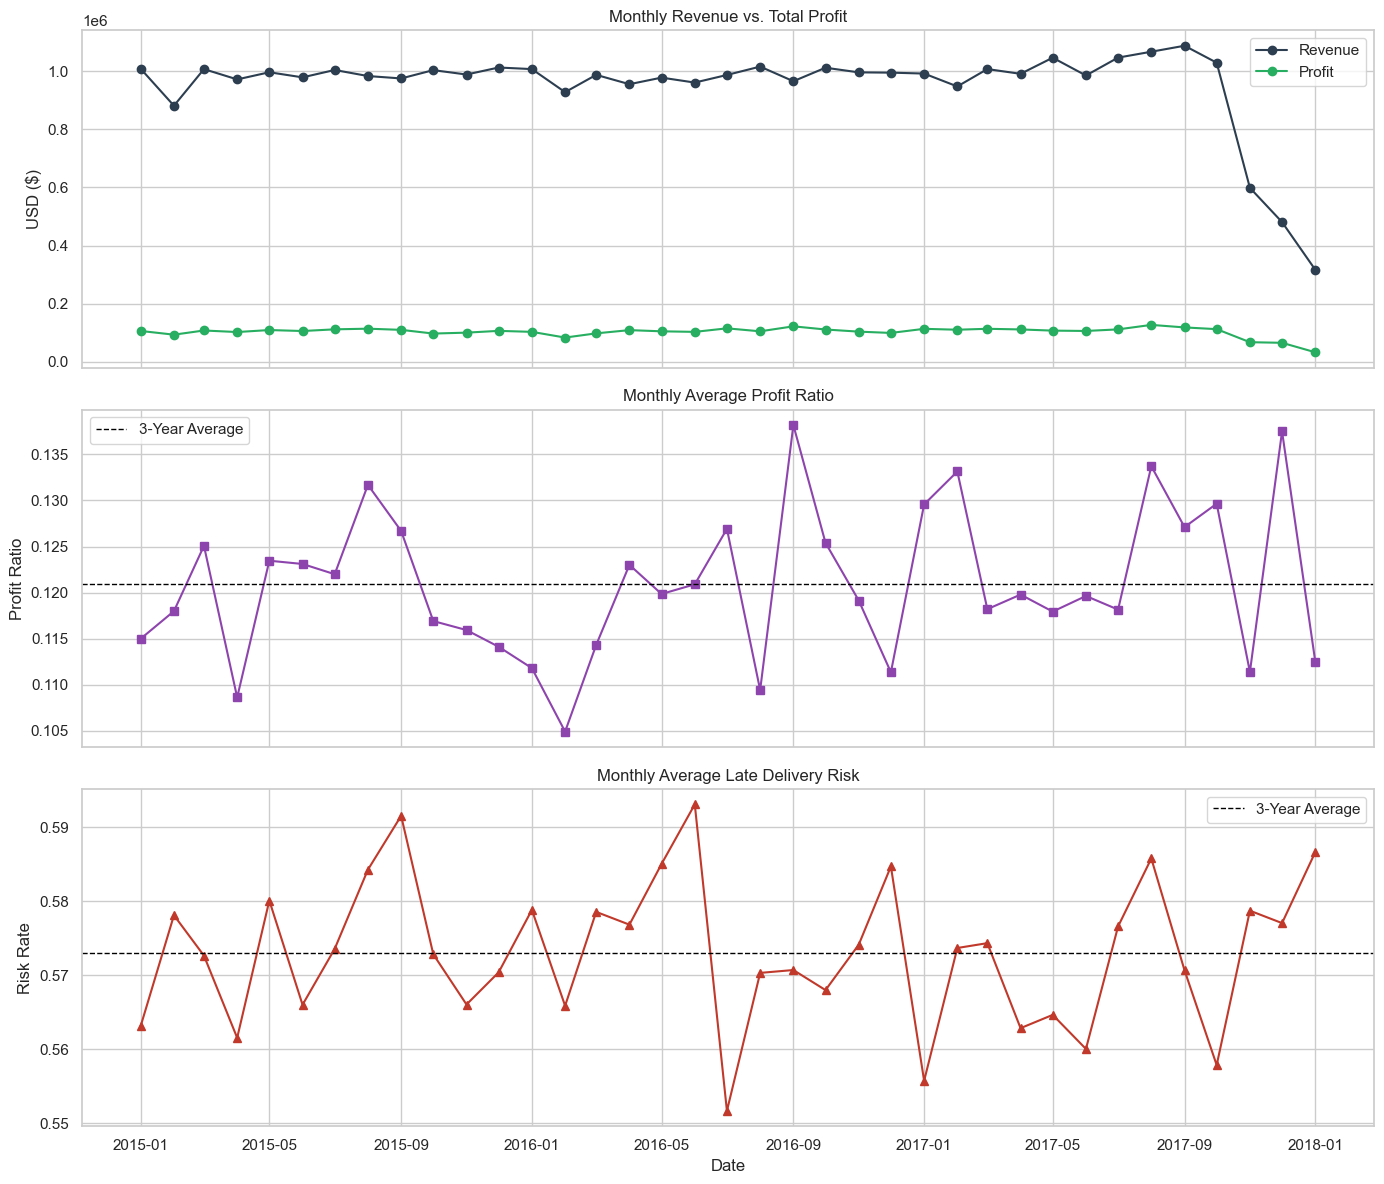

In [14]:
# Plotting Temporal Trends across 3 distinct axes
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Revenue & Profit Trend
axes[0].plot(temporal_df['month_date'], temporal_df['total_revenue'], color='#2c3e50', label='Revenue', marker='o')
axes[0].plot(temporal_df['month_date'], temporal_df['total_profit'], color='#27ae60', label='Profit', marker='o')
axes[0].set_title('Monthly Revenue vs. Total Profit')
axes[0].set_ylabel('USD ($)')
axes[0].legend()

# Profit Ratio Trend
axes[1].plot(temporal_df['month_date'], temporal_df['avg_profit_ratio'], color='#8e44ad', marker='s')
axes[1].axhline(temporal_df['avg_profit_ratio'].mean(), color='black', linestyle='--', linewidth=1, label='3-Year Average')
axes[1].set_title('Monthly Average Profit Ratio')
axes[1].set_ylabel('Profit Ratio')
axes[1].legend()

# Delivery Risk Trend
axes[2].plot(temporal_df['month_date'], temporal_df['avg_delivery_risk'], color='#c0392b', marker='^')
axes[2].axhline(temporal_df['avg_delivery_risk'].mean(), color='black', linestyle='--', linewidth=1, label='3-Year Average')
axes[2].set_title('Monthly Average Late Delivery Risk')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Risk Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

**Business Interpretation:**
* **Stagnation Leading to Collapse:** For nearly three years, top-line revenue and absolute profit were flatlined, indicating a complete lack of real growth. The sharp, catastrophic drop at the end of the dataset suggests a sudden demand collapse or severe supply chain break. 
* **Zero Operational Learning Curve:** A maturing business should see its profit margin stabilize and its delivery risk decrease over a 36-month period as processes improve. Here, both metrics remain highly erratic from the first month to the last. The business is not solving its fulfillment or pricing problems; it is merely surviving them month to month.
* **Chronic, Not Acute:** This confirms the operational failures identified earlier are not the result of a single bad quarter or a temporary logistical shock. The discount dependency and late delivery rates are chronic, structural realities of this supply chain.

## 10. EDA Summary & Ground Truths
Before moving to quadrant classification and composite risk scoring in Notebook 02, I have established the following empirical truths about the catalog:
* **Strict Validation:** The analytical dataframe perfectly reconciles with the SQL ground truth (118 products, $35.2M revenue, 12.08% overall profit ratio, 57.29% average delivery risk).
* **The Margin Illusion:** High top-line revenue does not indicate business health. Products like the `SOLE E35 Elliptical` generate massive scale (Rank 36 in revenue) but actively destroy aggregate profit (Rank 118 in profit, operating at -3.2% net margin).
* **The Discount Constant:** The business is entirely reliant on promotions. Transactions cluster heavily at a 94-96% discount dependency rate. The catalog does not know how to sell at full retail price.
* **The Toxic Core:** Five products (including major brands like Under Armour and ENO) represent the worst-case operational scenario: they require discounts >94% of the time, arrive late >60% of the time, and yield margins below 10%.
* **Systemic Stagnation:** Time-series analysis proves these operational failures are chronic. Margin and delivery risk remained highly volatile and fundamentally unimproved over the three-year lifecycle, culminating in a steep revenue collapse at the end of the period.